# **Classification of Liver Fibrosis Stages in Hepatitis C Patients Using Clinical and Demographic Data.**

# **Loading Dataset and Files**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the main dataset and the discretization criteria
df = pd.read_csv('HCV-Egy-Data.csv')
criteria = pd.read_csv('Discretization-Criteria.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
df.info()

# Display the first few rows
print("\nFirst 5 Rows of the Dataset:")
df.head()

Dataset Shape: (1385, 29)

Column Names and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385 entries, 0 to 1384
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               1385 non-null   int64  
 1   Gender                            1385 non-null   int64  
 2   BMI                               1385 non-null   int64  
 3   Fever                             1385 non-null   int64  
 4   Nausea/Vomting                    1385 non-null   int64  
 5   Headache                          1385 non-null   int64  
 6   Diarrhea                          1385 non-null   int64  
 7   Fatigue & generalized bone ache   1385 non-null   int64  
 8   Jaundice                          1385 non-null   int64  
 9   Epigastric pain                   1385 non-null   int64  
 10  WBC                               1385 non-null   int64  
 11  RBC          

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1


# **EDA**

## **Missing Values and Data Quality Check**

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0]) # Shows only columns with missing data



Missing values per column:
Series([], dtype: int64)


In [ ]:
# Summary statistics for numerical columns
summary_stats = df.describe().T
print("\nSummary Statistics:")
print(summary_stats)


Summary Statistics:
                                   count          mean            std  \
Age                               1385.0  4.631913e+01       8.781506   
Gender                            1385.0  1.489531e+00       0.500071   
BMI                               1385.0  2.860866e+01       4.076215   
Fever                             1385.0  1.515523e+00       0.499939   
Nausea/Vomting                    1385.0  1.502527e+00       0.500174   
Headache                          1385.0  1.496029e+00       0.500165   
Diarrhea                          1385.0  1.502527e+00       0.500174   
Fatigue & generalized bone ache   1385.0  1.498917e+00       0.500179   
Jaundice                          1385.0  1.501083e+00       0.500179   
Epigastric pain                   1385.0  1.503971e+00       0.500165   
WBC                               1385.0  7.533386e+03    2668.220333   
RBC                               1385.0  4.422130e+06  346357.711599   
HGB                           

## **Target Variable Analysis**

/tmp/ipython-input-4025709522.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Baselinehistological staging', data=df, palette='viridis')


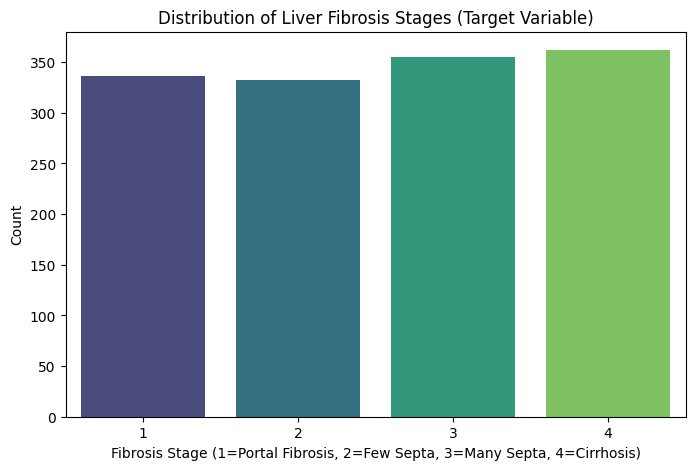

Stage Counts:
Baselinehistological staging
1    336
2    332
3    355
4    362
Name: count, dtype: int64


In [ ]:
# Distribution of the target variable: Liver Fibrosis Stages (1 to 4)
plt.figure(figsize=(8, 5))
sns.countplot(x='Baselinehistological staging', data=df, palette='viridis')
plt.title('Distribution of Liver Fibrosis Stages (Target Variable)')
plt.xlabel('Fibrosis Stage (1=Portal Fibrosis, 2=Few Septa, 3=Many Septa, 4=Cirrhosis)')
plt.ylabel('Count')
plt.savefig('target_distribution.png')
plt.show()

print("Stage Counts:")
print(df['Baselinehistological staging'].value_counts().sort_index())

## **Correlation Analysis**

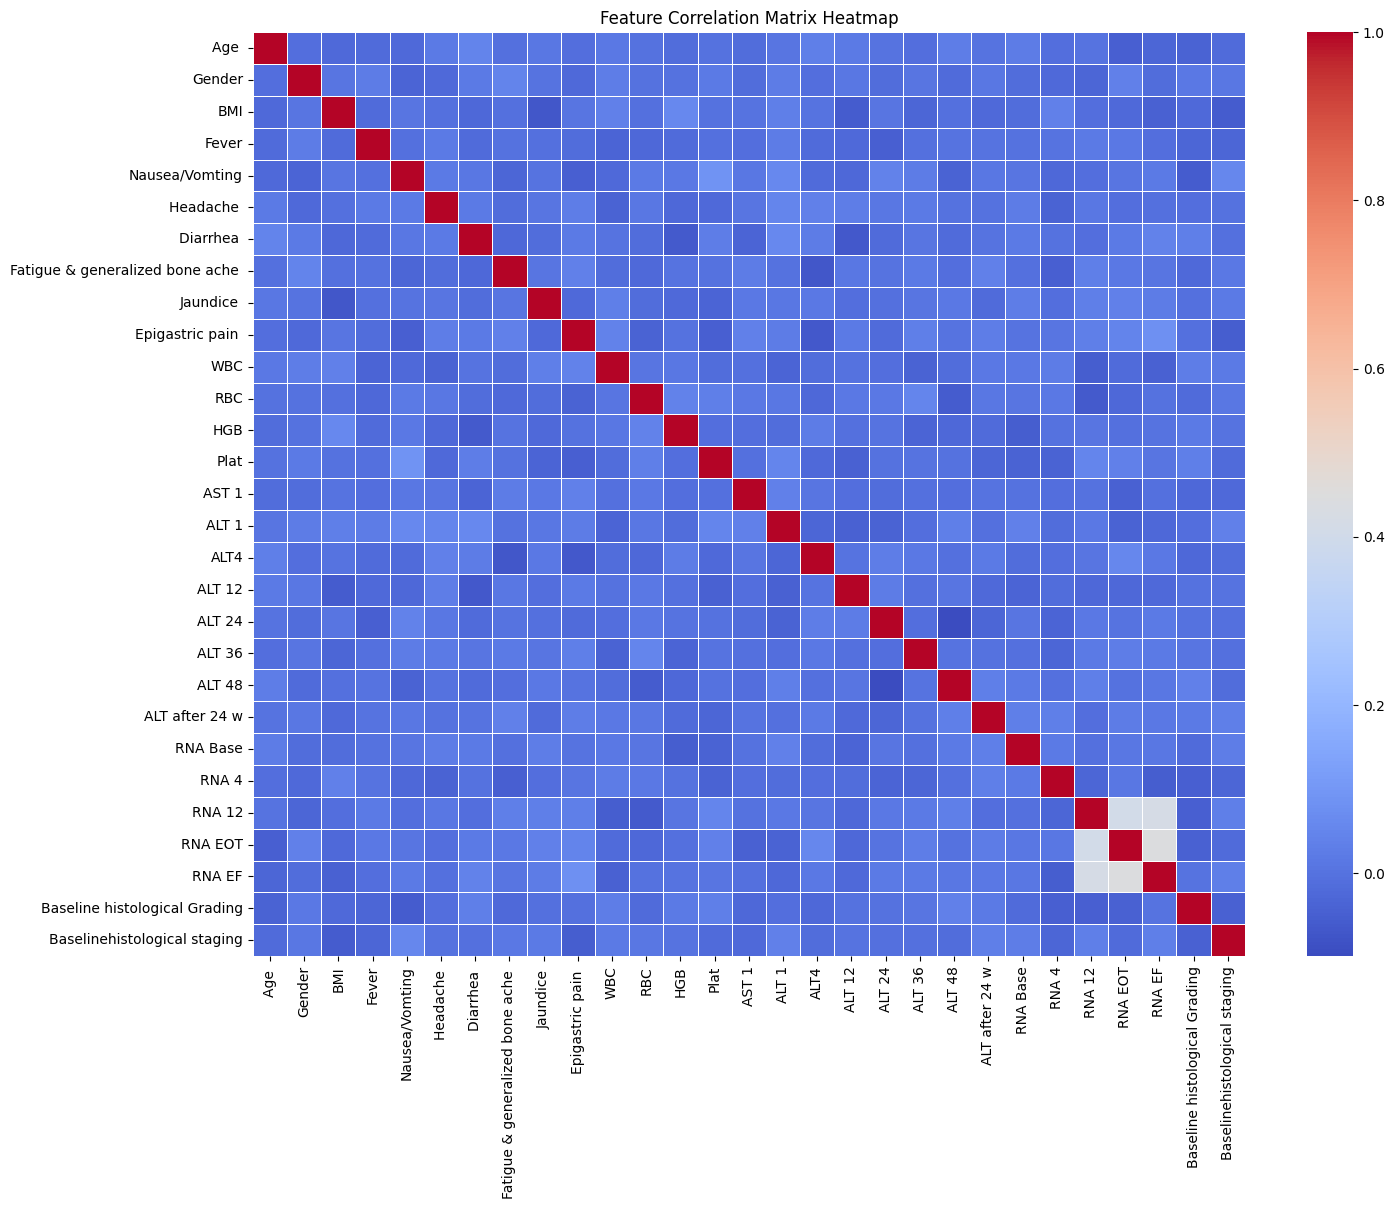


Correlation with Target (Baselinehistological staging):
Baselinehistological staging        1.000000
Nausea/Vomting                      0.054906
ALT 1                               0.036867
RNA 12                              0.034449
ALT after 24 w                      0.033919
RNA EF                              0.030519
RNA Base                            0.029411
Jaundice                            0.020219
WBC                                 0.017945
Fatigue & generalized bone ache     0.014563
Gender                              0.011955
RBC                                 0.009623
HGB                                 0.002752
ALT 12                              0.000809
Headache                           -0.001996
ALT 24                             -0.004888
Diarrhea                           -0.005639
ALT 36                             -0.006430
ALT 48                             -0.013533
ALT4                               -0.014997
Plat                               -0.01728

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap')
plt.savefig('correlation_matrix.png')
plt.show()

# Display correlations specifically with the target variable
print("\nCorrelation with Target (Baselinehistological staging):")
print(correlation_matrix['Baselinehistological staging'].sort_values(ascending=False))

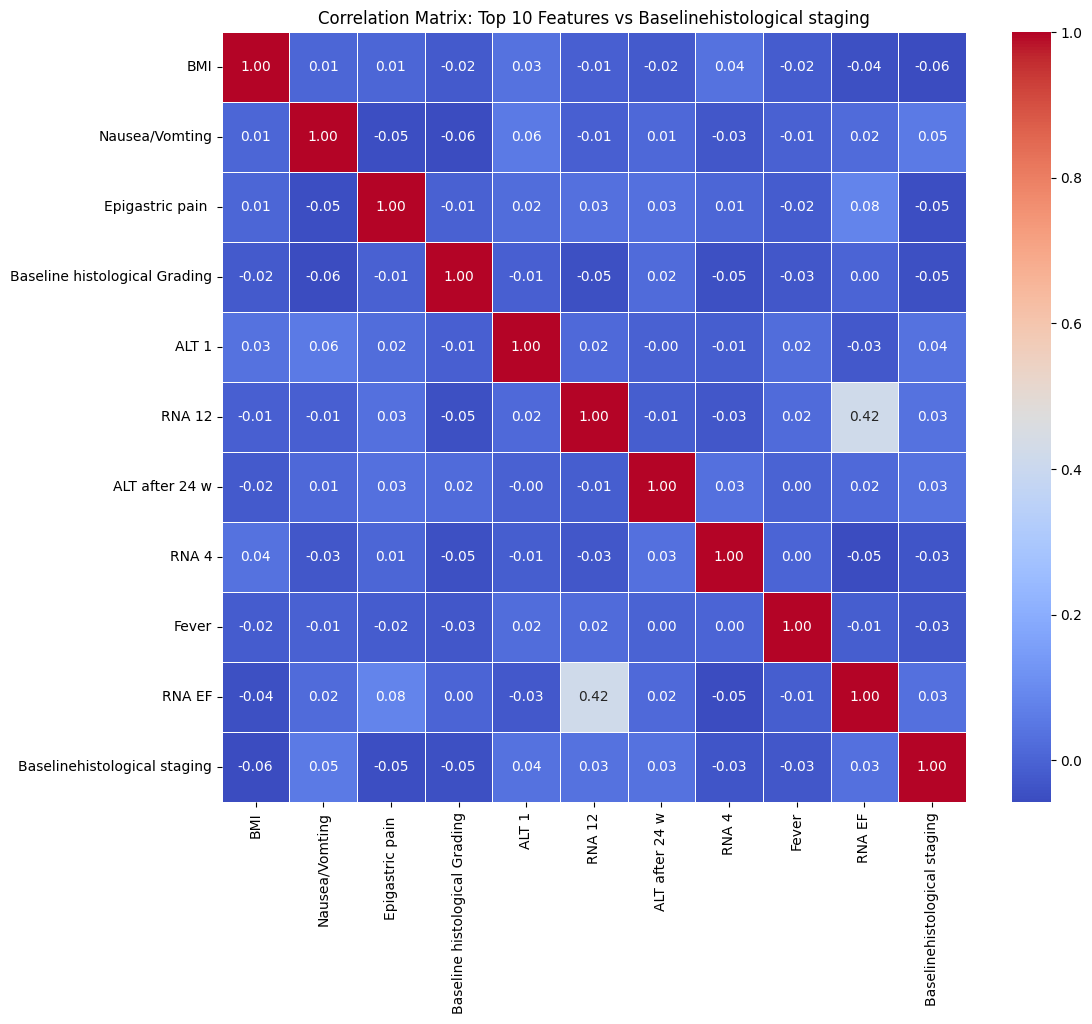

In [ ]:
# Define the target variable
target = 'Baselinehistological staging'

# Calculate absolute correlations with the target and sort them
correlations = df.corr()[target].abs().sort_values(ascending=False)

# Select top 10 features (excluding the target itself)
top_10_features = correlations.index[1:11].tolist()

# Create a subset including the target
subset_cols = top_10_features + [target]
correlation_matrix = df[subset_cols].corr()

# Visualize with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(f'Correlation Matrix: Top 10 Features vs {target}')
plt.savefig('top_10_correlation_matrix.png')
plt.show()

## **Continuous Variable Distributions**

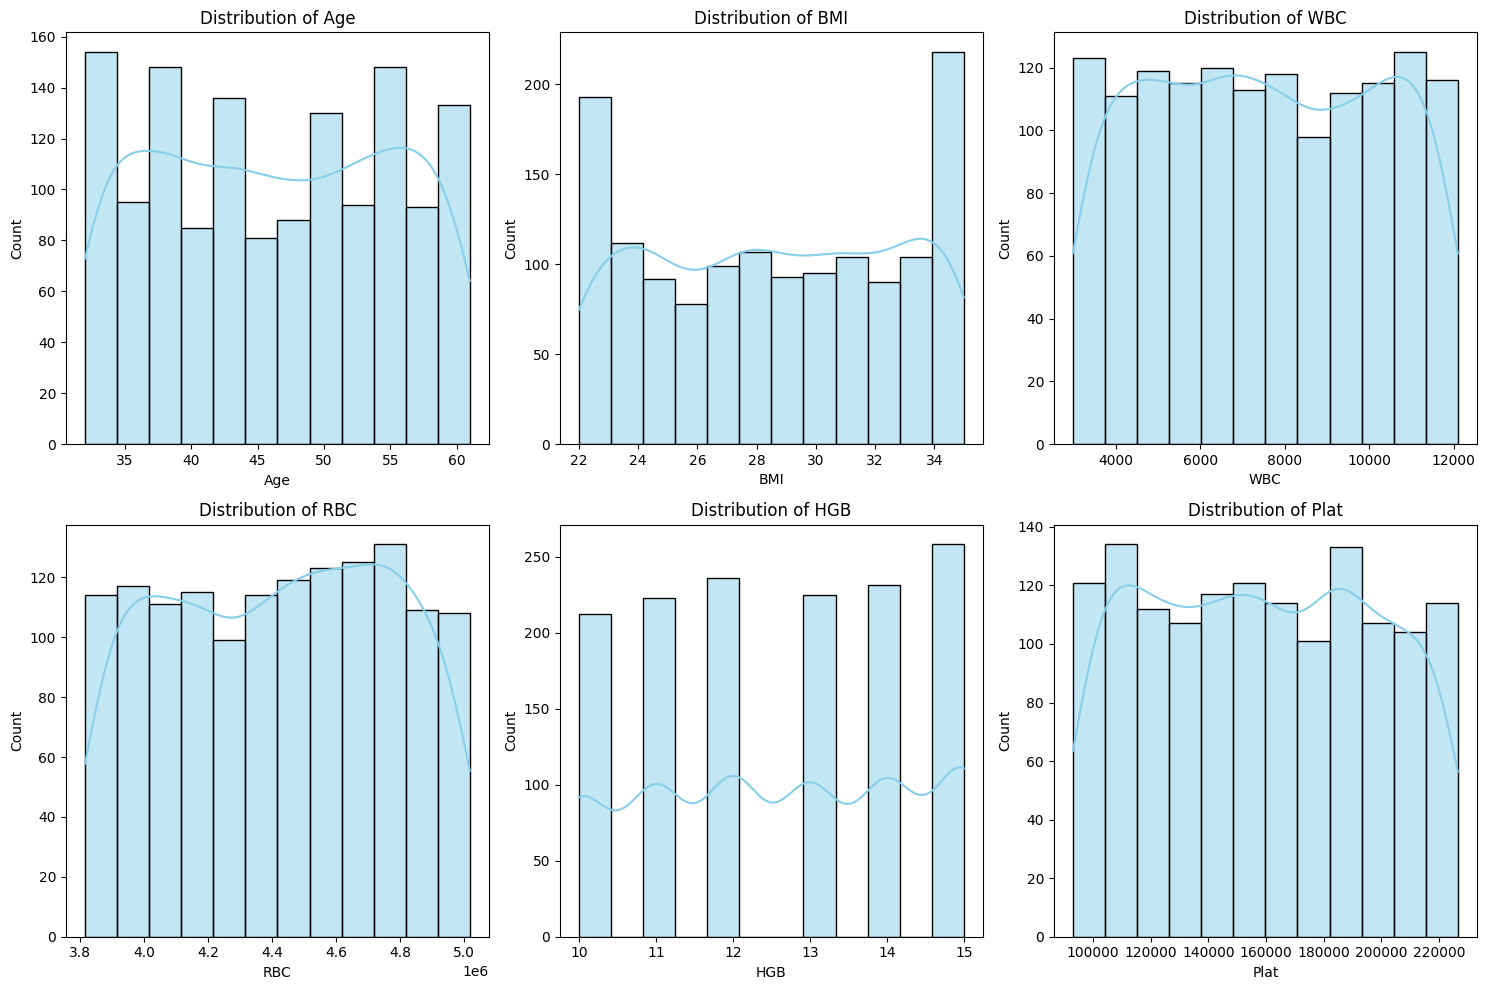

In [ ]:
continuous_cols = ['Age', 'BMI', 'WBC', 'RBC', 'HGB', 'Plat']

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('continuous_distributions.png')
plt.show()

## **Categorical Variable Analysis**

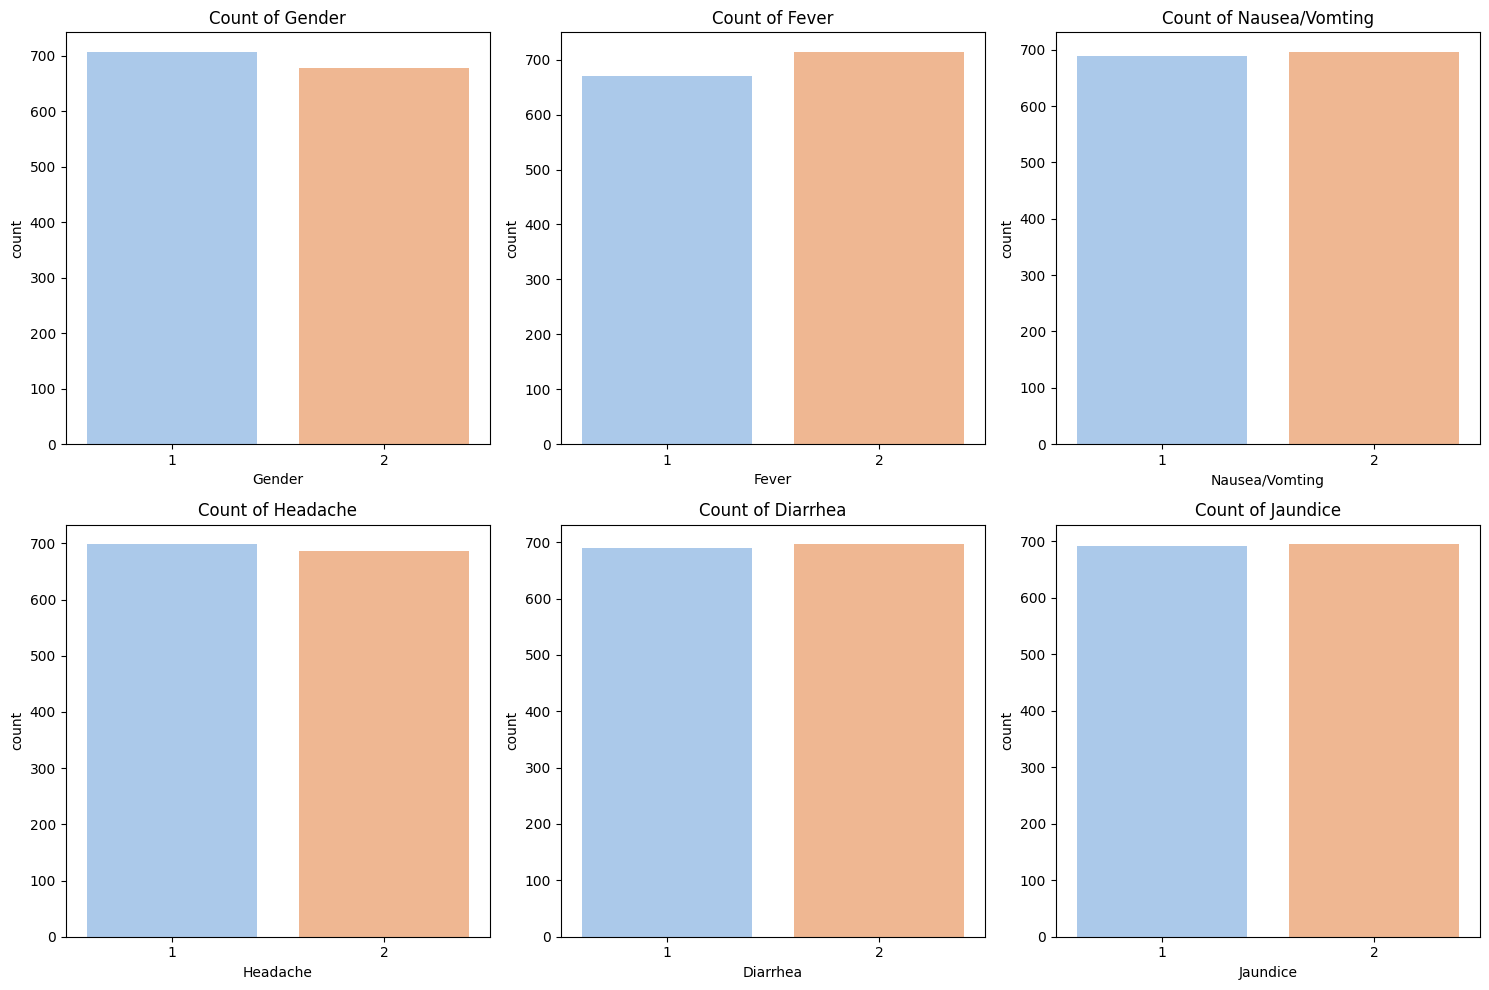

In [ ]:
# Bar plots for symptom/categorical variables
categorical_cols = ['Gender', 'Fever', 'Nausea/Vomting', 'Headache', 'Diarrhea', 'Jaundice']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=df, palette='pastel', hue=col, legend=False)
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.savefig('categorical_distributions.png')
plt.show()

In [ ]:
df.head()

,Age,Gender,BMI,Fever,Nausea/Vomting,Headache,Diarrhea,Fatigue & generalized bone ache,Jaundice,Epigastric pain,...,ALT 36,ALT 48,ALT after 24 w,RNA Base,RNA 4,RNA 12,RNA EOT,RNA EF,Baseline histological Grading,Baselinehistological staging
0,56,1,35,2,1,1,1,2,2,2,...,5,5,5,655330,634536,288194,5,5,13,2
1,46,1,29,1,2,2,1,2,2,1,...,57,123,44,40620,538635,637056,336804,31085,4,2
2,57,1,33,2,2,2,2,1,1,1,...,5,5,5,571148,661346,5,735945,558829,4,4
3,49,2,33,1,2,1,2,1,2,1,...,48,77,33,1041941,449939,585688,744463,582301,10,3
4,59,1,32,1,1,2,1,2,2,2,...,94,90,30,660410,738756,3731527,338946,242861,11,1


In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Cleaning Column Names
df.columns = df.columns.str.strip().str.replace('/', '_').str.replace(' ', '_')

# 2. Selecting relevant predictors (Demographics + Serum Labs)
# We exclude "future" RNA values to predict "Baseline" staging
features = ['Age', 'Gender', 'BMI', 'Fever', 'Nausea_Vomting', 'Headache',
            'Diarrhea', 'Fatigue_&_generalized_bone_ache', 'Jaundice',
            'Epigastric_pain', 'ALT_36', 'RNA_Base']
target = 'Baselinehistological_staging'

X = df[features].copy()
y = df[target].copy()

# 3. Encoding & Scaling
# Convert Gender to numeric if it's text
if X['Gender'].dtype == 'object':
    X['Gender'] = LabelEncoder().fit_transform(X['Gender'])

# XGBoost requires labels to start at 0 (your staging likely starts at 1)
y_encoded = y - y.min()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Initialize Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, kernel='rbf', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# Dictionary to store results
results = {}

for name, model in models.items():
    # Training Time
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    # Testing Time
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)
    test_time = time.time() - start_test

    results[name] = {
        "pred": y_pred,
        "prob": y_prob,
        "train_time": train_time,
        "test_time": test_time
    }

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

metrics_list = []

for name, res in results.items():
    metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, res['pred']),
        "F1-Score": f1_score(y_test, res['pred'], average='weighted'),
        "Precision": precision_score(y_test, res['pred'], average='weighted'),
        "Recall": recall_score(y_test, res['pred'], average='weighted'),
        "Train Time (s)": res['train_time'],
        "Test Time (s)": res['test_time']
    })

perf_df = pd.DataFrame(metrics_list).set_index("Model")
print(perf_df)

# Print detailed classification reports
for name in models.keys():
    print(f"\n--- Detailed Report: {name} ---")
    print(classification_report(y_test, results[name]['pred']))

               Accuracy  F1-Score  Precision    Recall  Train Time (s)  \
Model                                                                    
Random Forest  0.223827  0.224733   0.226331  0.223827        0.657498   
SVM            0.231047  0.229619   0.233900  0.231047        0.974439   
XGBoost        0.231047  0.230418   0.230234  0.231047        1.298315   

               Test Time (s)  
Model                         
Random Forest       0.052251  
SVM                 0.110249  
XGBoost             0.026733  

--- Detailed Report: Random Forest ---
              precision    recall  f1-score   support

           0       0.18      0.19      0.18        67
           1       0.24      0.24      0.24        67
           2       0.27      0.24      0.25        71
           3       0.22      0.22      0.22        72

    accuracy                           0.22       277
   macro avg       0.23      0.22      0.22       277
weighted avg       0.23      0.22      0.22       277


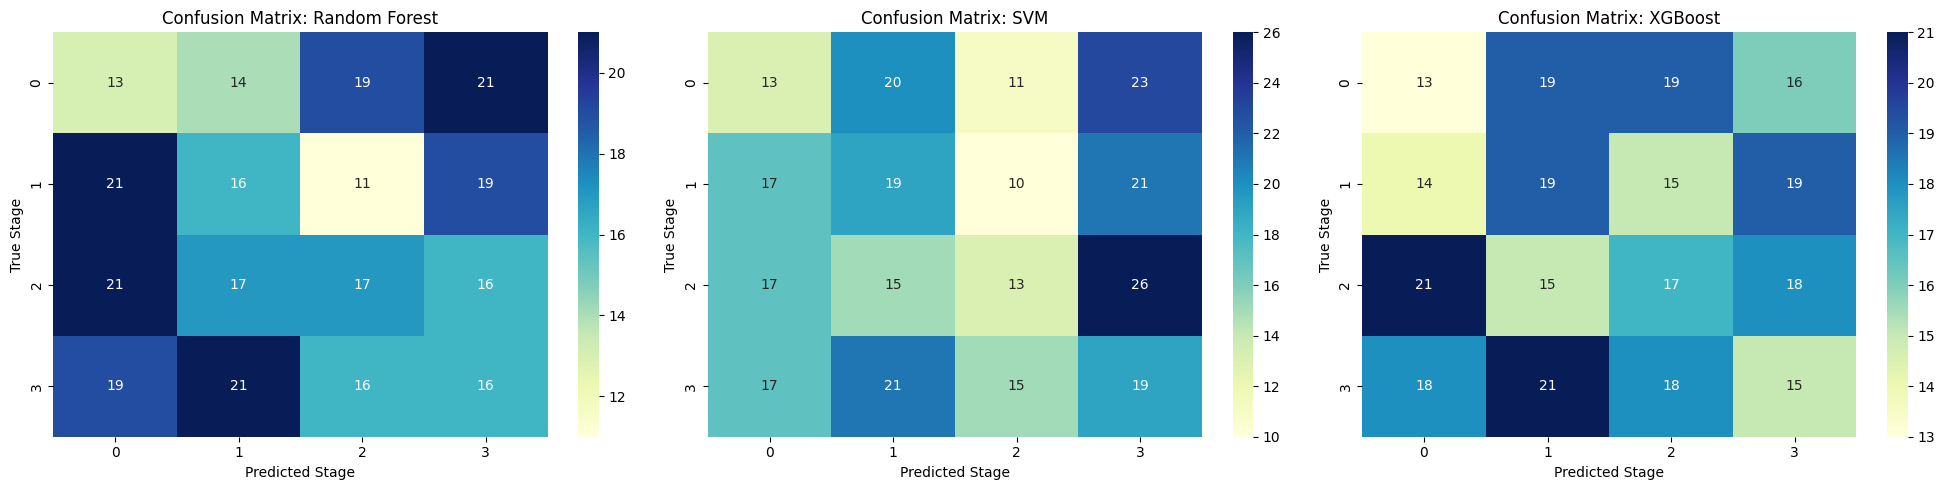

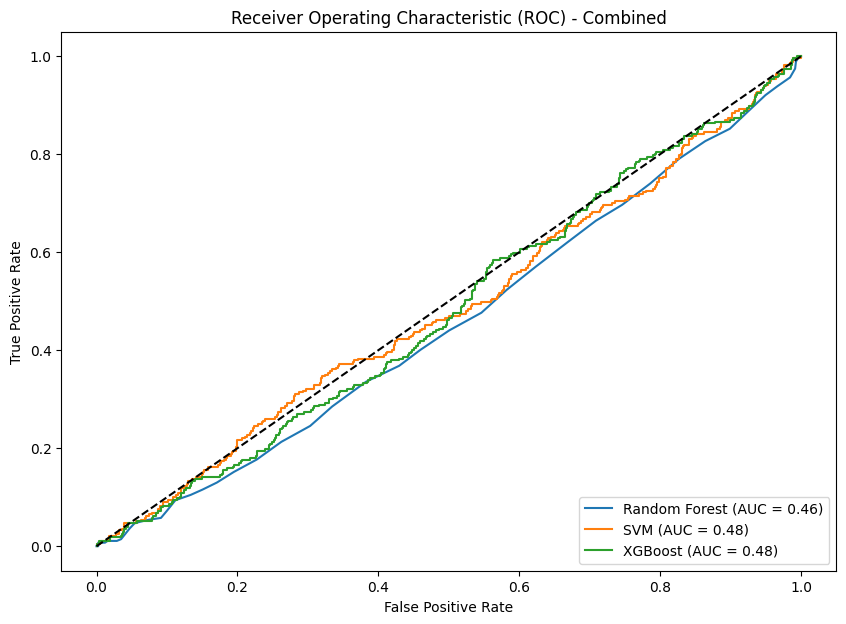

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Stage')
    axes[i].set_ylabel('True Stage')

plt.tight_layout()
plt.show()

# 2. ROC Curves (One-vs-Rest for multiclass)
y_test_bin = label_binarize(y_test, classes=np.unique(y_encoded))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))
for name, res in results.items():
    # Compute ROC for each model (Macro-average)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), res['prob'].ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Combined')
plt.legend(loc='lower right')
plt.show()

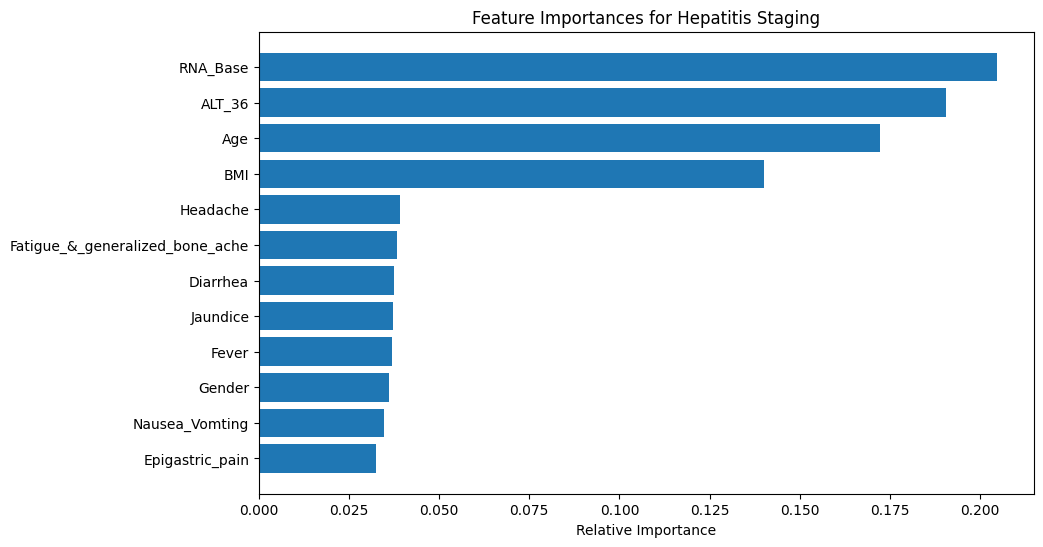

In [ ]:
import matplotlib.pyplot as plt

# Using Random Forest to see Feature Importance
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feat_names = features
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances for Hepatitis Staging")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a search grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

print("Starting Grid Search... this may take a moment.")
grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluate the tuned model
best_rf = grid_search.best_estimator_
tuned_pred = best_rf.predict(X_test_scaled)
print("\nUpdated Classification Report (Tuned RF):")
print(classification_report(y_test, tuned_pred))

Starting Grid Search... this may take a moment.
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.2798

Updated Classification Report (Tuned RF):
              precision    recall  f1-score   support

           0       0.11      0.10      0.11        67
           1       0.20      0.21      0.20        67
           2       0.34      0.32      0.33        71
           3       0.22      0.24      0.23        72

    accuracy                           0.22       277
   macro avg       0.22      0.22      0.22       277
weighted avg       0.22      0.22      0.22       277

